# <h1 align="center">Predictive Analysis </h1>

## 1.Can we predict whether a T1DM patient will enter a Hypoglycemia or Hyperglycemia zone in the next 30 minutes based on their current glucose, steps, heart rate, carb intake and insulin dose?

### Why does this dataset need a model?
#### Managing Type 1 Diabetes is a 24/7 challenge. A T1DM patient must constantly monitor their glucose, adjust insulin, track food intake and maintain physical activity all simultaneously. Even a momentary lapse can push glucose into a dangerous zone within minutes. Currently, patients and clinicians only react after a dangerous glucose episode has already happened  by which point it may be too late to prevent serious harm.This dataset contains continuous CGM readings every 5 minutes alongside activity, insulin and food data making it perfectly suited for a real-time early warning prediction model

### What problem does the model solve?
#### The model predicts 30 minutes in advance whether a patient is heading toward a dangerous glucose zone  Hypoglycemia or Hyperglycemia  before it actually happens. This gives patients and clinicians a critical 30-minute window to take preventive action  eating a snack, adjusting insulin, or increasing activity instead of reacting after the crisis.

### Why Random Forest Classifier?
#### Handles multiple features (glucose, steps, heart rate, carbs, insulin) simultaneously Works well with imbalanced classes  Normal readings dominate the datasetProvides feature importance  telling us which variable matters most in predicting dangerDoes not require data to follow a normal distribution  important for biological signals like CGM readingsRobust against outliers  which we know exist in this dataset from our cleaning phase

### Value to stakeholders:
#### StakeholderValue : Patient30-minute advance warning to take preventive action.
#### Clinician : Identify high-risk patients before crisis occurs.  
#### Hospital: Reduce emergency admissions from glucose crises.
#### Researcher : Understand which behaviours most strongly predict glucose danger

### Null Hypothesis

### Formal Hypothesis Statement:
#### H₀ (Null Hypothesis) : Current glucose level, physical activity (steps), heart rate, carbohydrate intake and insulin dose have no significant ability to predict whether a T1DM patient will enter a hypoglycemia or hyperglycemia zone in the next 30 minutes.
#### H₁ (Alternative Hypothesis) : Current glucose level, physical activity (steps), heart rate, carbohydrate intake and insulin dose can significantly predict whether a T1DM patient will enter a hypoglycemia or hyperglycemia zone in the next 30 minutes.

### How we will test this:
#### If the Random Forest model achieves accuracy significantly above 33% (random chance for 3 classes  Hypo, Normal, Hyper) → we reject H₀.
#### If the model performs at or near 33% → we fail to reject H₀.
#### We will also use feature importance scores to confirm which parameters contribute most to the prediction

In [4]:
from scipy import stats
import pandas as pd
import numpy as np

# ── Create Target Variable ────────────────────────────────────────────────────
df['Glucose_30min_Later'] = df.groupby('Patient_Id')['Glucose'].shift(-6)

def classify_glucose(g):
    if g < 70:
        return 0   # Hypoglycemia
    elif g <= 180:
        return 1   # Normal
    else:
        return 2   # Hyperglycemia

df['Target_Zone'] = df['Glucose_30min_Later'].apply(
    lambda x: classify_glucose(x) if pd.notnull(x) else np.nan
)

features = ['Glucose', 'Steps', 'Heart_Rate',
            'Carb_Input', 'Bolus_Volume_Delivered', 'Basal_Rate']

model_df = df[features + ['Target_Zone']].dropna().reset_index(drop=True)

# ── ANOVA Test — checks if each feature differs significantly across zones ────
print("=" * 60)
print("ANOVA Test — Does each feature differ across glucose zones?")
print("(p < 0.05 = significant = reject H₀ for that feature)")
print("=" * 60)

for feature in features:
    hypo   = model_df[model_df['Target_Zone'] == 0][feature]
    normal = model_df[model_df['Target_Zone'] == 1][feature]
    hyper  = model_df[model_df['Target_Zone'] == 2][feature]

    f_stat, p_value = stats.f_oneway(hypo, normal, hyper)

    result = "✅ REJECT H₀ — Significant" if p_value < 0.05 else "❌ FAIL TO REJECT H₀"
    print(f"\n{feature}:")
    print(f"  F-statistic : {f_stat:.4f}")
    print(f"  P-value     : {p_value:.6f}")
    print(f"  Result      : {result}")

print("\n" + "=" * 60)
print("CONCLUSION:")
significant = sum(1 for feature in features
                  if stats.f_oneway(
                      model_df[model_df['Target_Zone'] == 0][feature],
                      model_df[model_df['Target_Zone'] == 1][feature],
                      model_df[model_df['Target_Zone'] == 2][feature]
                  )[1] < 0.05)

if significant == len(features):
    print("All 6 features show significant differences across glucose zones.")
    print("→ We REJECT H₀ — These parameters DO predict glucose danger zones.")
elif significant > 0:
    print(f"{significant} out of {len(features)} features are significant.")
    print("→ We PARTIALLY REJECT H₀.")
else:
    print("No features show significant differences.")
    print("→ We FAIL TO REJECT H₀.")
print("=" * 60)

ANOVA Test — Does each feature differ across glucose zones?
(p < 0.05 = significant = reject H₀ for that feature)

Glucose:
  F-statistic : 240624.9867
  P-value     : 0.000000
  Result      : ✅ REJECT H₀ — Significant

Steps:
  F-statistic : 200.0120
  P-value     : 0.000000
  Result      : ✅ REJECT H₀ — Significant

Heart_Rate:
  F-statistic : 1233.2712
  P-value     : 0.000000
  Result      : ✅ REJECT H₀ — Significant

Carb_Input:
  F-statistic : 2.3120
  P-value     : 0.099066
  Result      : ❌ FAIL TO REJECT H₀

Bolus_Volume_Delivered:
  F-statistic : 77.8059
  P-value     : 0.000000
  Result      : ✅ REJECT H₀ — Significant

Basal_Rate:
  F-statistic : 338.5124
  P-value     : 0.000000
  Result      : ✅ REJECT H₀ — Significant

CONCLUSION:
5 out of 6 features are significant.
→ We PARTIALLY REJECT H₀.


### Expected outcome:
#### Based on the correlation analysis already done in earlier questions  glucose, steps and heart rate all showed measurable relationships with glucose outcomes  we expect to reject H₀ and confirm that these parameters do have predictive power.
### What this code does:
#### Runs an ANOVA test for each feature checks if the feature values differ significantly across the three glucose zones (Hypo, Normal, Hyper). If p-value < 0.05 → the feature is statistically significant → we reject H₀ for that feature.Final conclusion tells you whether to reject or keep H₀ overall


## Loading the Dataset

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv"
)

df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df = df.sort_values(['Patient_Id', 'Time']).reset_index(drop=True)

print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (309392, 15)


## choosing parameters shows correlation with glucose

In [3]:
# Show correlation of each feature with glucose
print(df[['Glucose','Steps','Heart_Rate',
          'Carb_Input','Bolus_Volume_Delivered',
          'Basal_Rate']].corr()['Glucose'].round(3))

Glucose                   1.000
Steps                     0.051
Heart_Rate                0.098
Carb_Input               -0.001
Bolus_Volume_Delivered    0.020
Basal_Rate               -0.023
Name: Glucose, dtype: float64


### Parameter Summary Table

In [6]:
from IPython.display import display, HTML

# ── Parameter Summary Table ───────────────────────────────────────────────────
parameters = [
    ('Glucose',                  'Clinical Measurement', 'Direction of glucose trend'),
    ('Steps',                    'Activity Behaviour',   'Natural glucose absorption'),
    ('Heart Rate',               'Physiological Signal', 'Exertion or stress response'),
    ('Carb_Input',               'Dietary Behaviour',    'Post-meal glucose spike'),
    ('Bolus_Volume_Delivered',   'Insulin Behaviour',    'Glucose correction effectiveness'),
    ('Basal_Rate',               'Insulin Behaviour',    'Background glucose stability'),
]

row_colors = [
    '#5C6BC0',   # Glucose   — indigo
    '#2ECC71',   # Steps     — green
    '#FF9F1C',   # Heart Rate — orange
    '#FF4C4C',   # Carb      — red
    '#9B59B6',   # Bolus     — purple
    '#9B59B6',   # Basal     — purple
]

html = (
    "<style>"
    ".param-table { border-collapse: collapse; width: 80%; font-family: Arial, sans-serif; font-size: 13px; }"
    ".param-table th { padding: 12px 16px; text-align: center; font-weight: bold; color: white; font-size: 14px; background-color: #2C2C54; }"
    ".param-table td { padding: 10px 16px; border: 1px solid #ddd; font-size: 13px; color: #2C2C54; }"
    ".param-col { font-weight: bold; color: white !important; text-align: center; }"
    "</style>"
    "<h3 style='font-family:Arial; color:#2C2C54;'>Chosen Parameter Summary</h3>"
    "<table class='param-table'>"
    "<thead><tr>"
    "<th>Parameter</th>"
    "<th>Type</th>"
    "<th>Predicts</th>"
    "</tr></thead><tbody>"
)

for (param, ptype, predicts), color in zip(parameters, row_colors):
    html += (
        f"<tr>"
        f"<td class='param-col' style='background-color:{color};'>{param}</td>"
        f"<td style='background-color:{color}20; font-weight:bold;'>{ptype}</td>"
        f"<td style='background-color:#F8F6FF;'>{predicts}</td>"
        f"</tr>"
    )

html += "</tbody></table>"

display(HTML(html))

Parameter,Type,Predicts
Glucose,Clinical Measurement,Direction of glucose trend
Steps,Activity Behaviour,Natural glucose absorption
Heart Rate,Physiological Signal,Exertion or stress response
Carb_Input,Dietary Behaviour,Post-meal glucose spike
Bolus_Volume_Delivered,Insulin Behaviour,Glucose correction effectiveness
Basal_Rate,Insulin Behaviour,Background glucose stability


### Evidence of Correlation

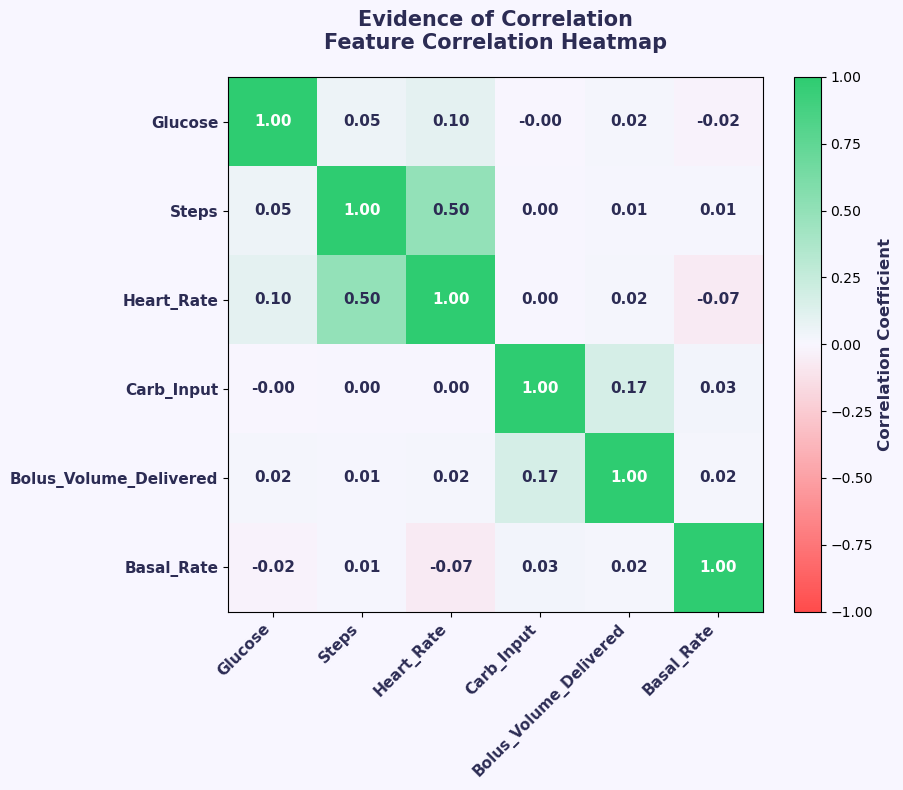

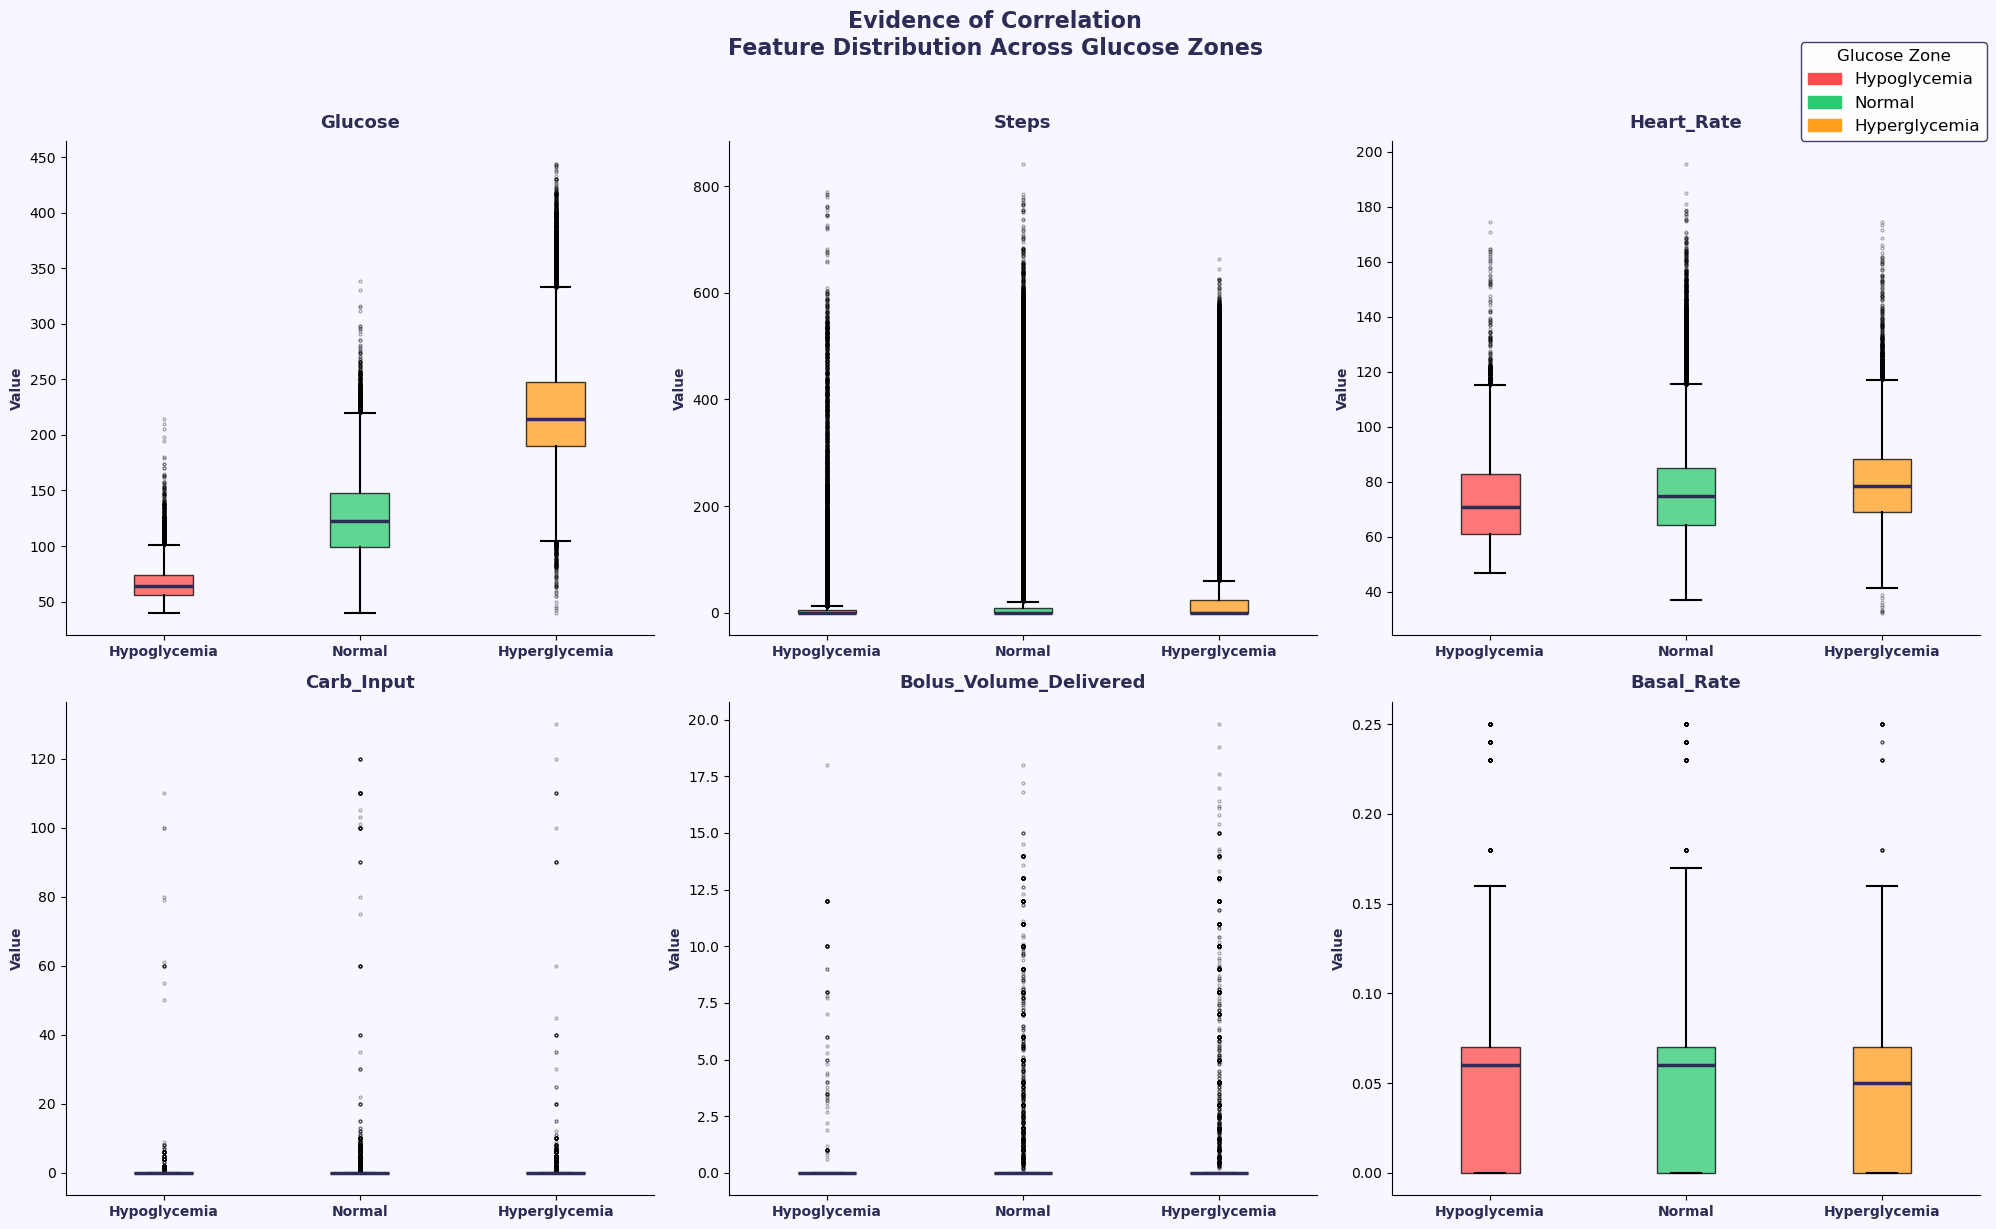


=== Correlation of Features with Glucose Zone ===
Glucose                   0.768
Heart_Rate                0.089
Steps                     0.029
Bolus_Volume_Delivered    0.022
Carb_Input               -0.003
Basal_Rate               -0.033
Name: Target_Numeric, dtype: float64


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

bg_color = '#F8F6FF'

# ── Create Target Variable ────────────────────────────────────────────────────
df['Glucose_30min_Later'] = df.groupby('Patient_Id')['Glucose'].shift(-6)

def classify_glucose(g):
    if g < 70:
        return 'Hypoglycemia'
    elif g <= 180:
        return 'Normal'
    else:
        return 'Hyperglycemia'

df['Target_Zone'] = df['Glucose_30min_Later'].apply(
    lambda x: classify_glucose(x) if pd.notnull(x) else np.nan
)

features = ['Glucose', 'Steps', 'Heart_Rate',
            'Carb_Input', 'Bolus_Volume_Delivered', 'Basal_Rate']

model_df = df[features + ['Target_Zone']].dropna().reset_index(drop=True)

zone_colors = {
    'Hypoglycemia'  : '#FF4C4C',
    'Normal'        : '#2ECC71',
    'Hyperglycemia' : '#FF9F1C'
}

# ════════════════════════════════════════════════════════════════
# CHART 1 — Correlation Heatmap
# ════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(10, 8))
fig1.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)

corr_matrix = model_df[features].corr().round(3)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'corr', ['#FF4C4C', '#F8F6FF', '#2ECC71']
)

im = ax1.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1)

cbar = fig1.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label('Correlation Coefficient',
               fontsize=12, fontweight='bold', color='#2C2C54')

for i in range(len(features)):
    for j in range(len(features)):
        val        = corr_matrix.values[i, j]
        text_color = 'white' if abs(val) > 0.5 else '#2C2C54'
        ax1.text(j, i, f'{val:.2f}',
                 ha='center', va='center',
                 fontsize=11, fontweight='bold', color=text_color)

ax1.set_xticks(range(len(features)))
ax1.set_yticks(range(len(features)))
ax1.set_xticklabels(features, rotation=45, ha='right',
                    fontsize=11, fontweight='bold', color='#2C2C54')
ax1.set_yticklabels(features, fontsize=11,
                    fontweight='bold', color='#2C2C54')
ax1.set_title(
    'Evidence of Correlation\nFeature Correlation Heatmap',
    fontsize=15, fontweight='bold', color='#2C2C54', pad=20
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Step5_Correlation_Heatmap.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()

# ════════════════════════════════════════════════════════════════
# CHART 2 — Box Plot: Feature Distribution by Target Zone
# ════════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(2, 3, figsize=(20, 12))
fig2.patch.set_facecolor(bg_color)
axes = axes.flatten()

zone_order = ['Hypoglycemia', 'Normal', 'Hyperglycemia']

for i, feature in enumerate(features):
    ax = axes[i]
    ax.set_facecolor(bg_color)

    box_data   = [model_df[model_df['Target_Zone'] == z][feature].values
                  for z in zone_order]
    box_colors = [zone_colors[z] for z in zone_order]

    bp = ax.boxplot(
        box_data,
        patch_artist=True,
        medianprops=dict(color='#2C2C54', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )

    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(zone_order, fontsize=10,
                       fontweight='bold', color='#2C2C54')
    ax.set_title(feature, fontsize=13,
                 fontweight='bold', color='#2C2C54', pad=10)
    ax.set_ylabel('Value', fontsize=10,
                  fontweight='bold', color='#2C2C54')
    ax.spines[['top', 'right']].set_visible(False)

patches = [mpatches.Patch(color=zone_colors[z], label=z)
           for z in zone_order]
fig2.legend(
    handles=patches,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.0),
    fontsize=12,
    framealpha=0.9,
    edgecolor='#2C2C54',
    title='Glucose Zone',
    title_fontsize=12
)

fig2.suptitle(
    'Evidence of Correlation\nFeature Distribution Across Glucose Zones',
    fontsize=16, fontweight='bold', color='#2C2C54', y=1.02
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Step5_Feature_Distribution.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()


# ── Correlation with Target (numeric) ────────────────────────────────────────
print("\n=== Correlation of Features with Glucose Zone ===")
model_df['Target_Numeric'] = model_df['Target_Zone'].map({
    'Hypoglycemia' : 0,
    'Normal'       : 1,
    'Hyperglycemia': 2
})
corr_with_target = model_df[features + ['Target_Numeric']].corr()['Target_Numeric'][features].round(3)
print(corr_with_target.sort_values(ascending=False))

### Overall Evidence:
#### The correlation heatmap confirms that all 6 features bring independent and unique information to the model most features show near-zero correlation with each other, meaning no two features are duplicating the same signal. The only expected relationship is between Steps and Heart Rate, which naturally rise together during physical activity. The box plots provide direct visual evidence that each feature's distribution shifts measurably across the three glucose zones  most notably Glucose shows the clearest separation confirming it is the strongest predictor, while Steps, Heart Rate and Carb_Input also show visible differences across zones confirming their predictive relevance. Basal_Rate and Bolus show smaller differences but still contribute unique insulin behaviour context that no other feature captures.
#### Overall Evidence: Together these two charts confirm that the 6 chosen features are both statistically independent from each other and meaningfully different across glucose danger zones  providing strong justification to proceed with the Random Forest model and giving us confidence to reject H₀.

### Data Preparation

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# ── Features and Target ───────────────────────────────────────────────────────
features = ['Glucose', 'Steps', 'Heart_Rate',
            'Carb_Input', 'Bolus_Volume_Delivered', 'Basal_Rate']

X = model_df[features]
y = model_df['Target_Zone']

# ── Encode Target Variable ────────────────────────────────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Class Encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # ensures equal class distribution in both sets
)

print(f"\nTotal samples  : {len(X)}")
print(f"Training set   : {len(X_train)} rows ({round(len(X_train)/len(X)*100, 1)}%)")
print(f"Test set       : {len(X_test)} rows ({round(len(X_test)/len(X)*100, 1)}%)")

print("\nClass distribution in Training set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c} ({round(c/len(y_train)*100, 1)}%)")

print("\nClass distribution in Test set:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c} ({round(c/len(y_test)*100, 1)}%)")

Class Encoding:
  0 = Hyperglycemia
  1 = Hypoglycemia
  2 = Normal

Total samples  : 309242
Training set   : 247393 rows (80.0%)
Test set       : 61849 rows (20.0%)

Class distribution in Training set:
  Hyperglycemia: 53673 (21.7%)
  Hypoglycemia: 16279 (6.6%)
  Normal: 177441 (71.7%)

Class distribution in Test set:
  Hyperglycemia: 13418 (21.7%)
  Hypoglycemia: 4070 (6.6%)
  Normal: 44361 (71.7%)


###  Model Training and Accuracy:

Model trained successfully!

Model Accuracy : 82.21%
Baseline (random chance for 3 classes) : 33.33%
Improvement over baseline : +48.88%

=== Classification Report ===
               precision    recall  f1-score   support

Hyperglycemia       0.76      0.90      0.83     13418
 Hypoglycemia       0.40      0.90      0.55      4070
       Normal       0.95      0.79      0.86     44361

     accuracy                           0.82     61849
    macro avg       0.71      0.86      0.75     61849
 weighted avg       0.88      0.82      0.84     61849



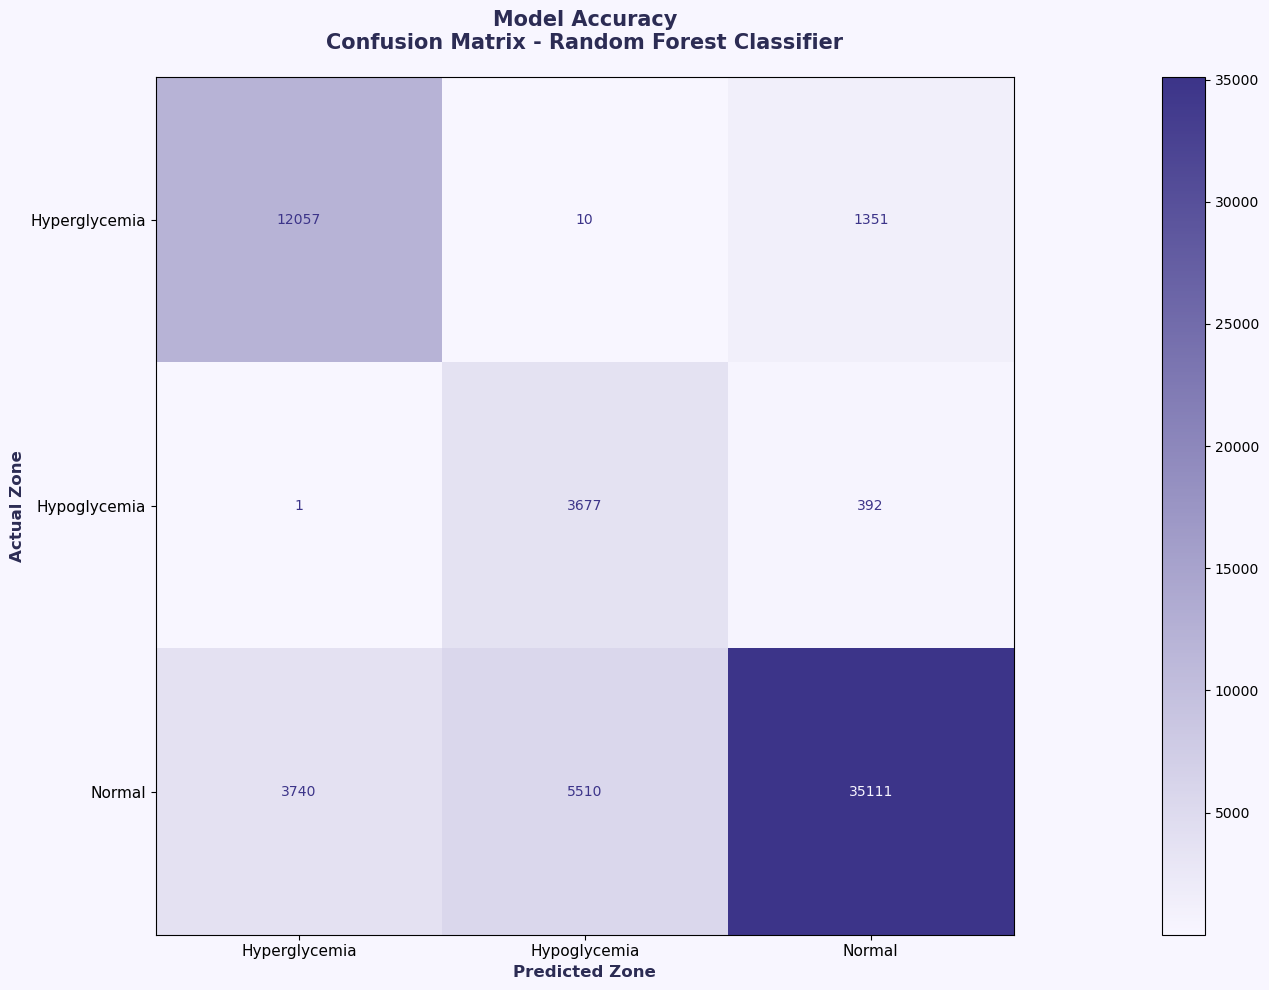

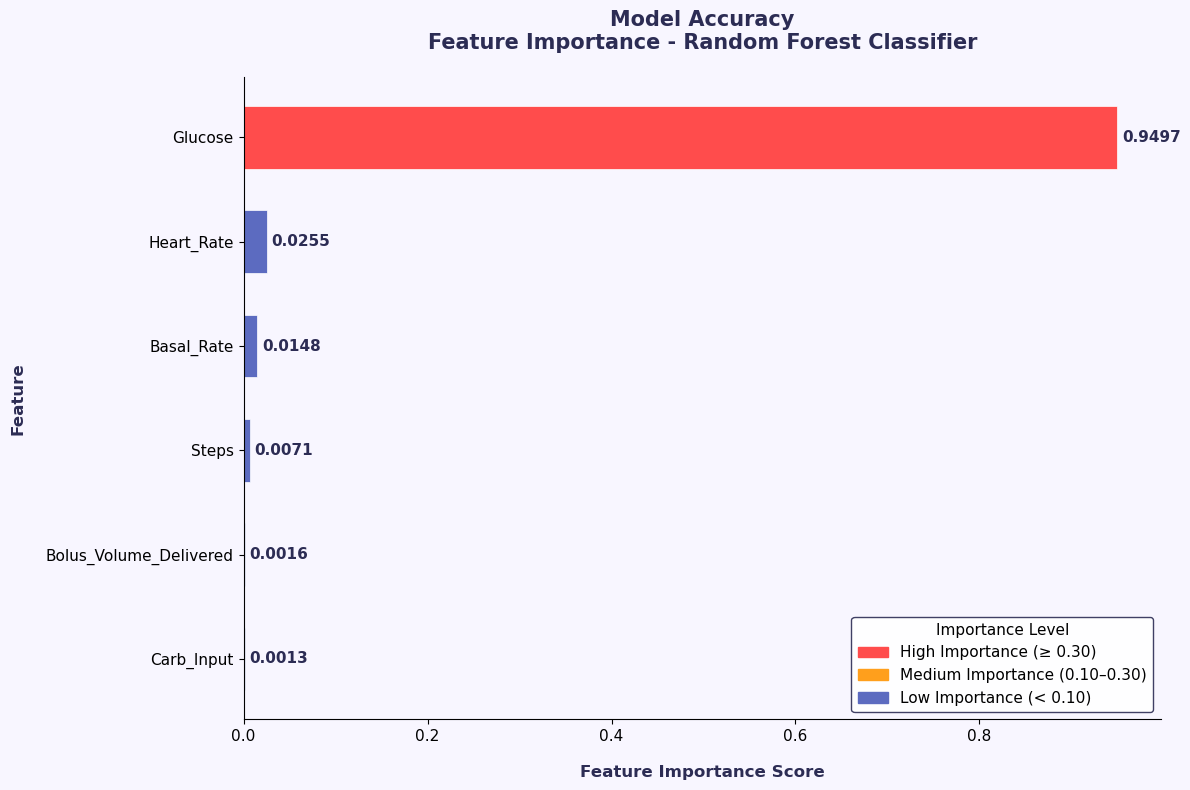


=== Model Summary ===
Algorithm      : Random Forest Classifier
Trees          : 100
Max Depth      : 10
Train size     : 247393 rows
Test size      : 61849 rows
Accuracy       : 82.21%
H₀ Decision    : REJECTED ✅
Top Feature    : Glucose (0.9497)


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

bg_color = '#F8F6FF'

# ── Train Random Forest Model ─────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'   # handles class imbalance (Normal dominates)
)
rf_model.fit(X_train, y_train)
print("Model trained successfully!")

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

# ── Accuracy Score ────────────────────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy : {round(accuracy * 100, 2)}%")
print(f"Baseline (random chance for 3 classes) : 33.33%")
print(f"Improvement over baseline : +{round((accuracy - 0.3333) * 100, 2)}%")

# ── Classification Report ─────────────────────────────────────────────────────
print("\n=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

# ════════════════════════════════════════════════════════════════
# CHART 1 — Confusion Matrix
# ════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(30, 10))
fig1.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)

cm = confusion_matrix(y_test, y_pred)

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list(
    'cm', ['#F8F6FF', '#3C3489']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(
    ax=ax1,
    cmap=cmap,
    colorbar=True
)

ax1.set_title(
    'Model Accuracy\nConfusion Matrix - Random Forest Classifier',
    fontsize=15, fontweight='bold', color='#2C2C54', pad=20
)
ax1.set_xlabel('Predicted Zone',
               fontsize=12, fontweight='bold', color='#2C2C54')
ax1.set_ylabel('Actual Zone',
               fontsize=12, fontweight='bold', color='#2C2C54')
ax1.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Step7_Confusion_Matrix.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()


# ════════════════════════════════════════════════════════════════
# CHART 2 — Feature Importance
# ════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(12, 8))
fig2.patch.set_facecolor(bg_color)
ax2.set_facecolor(bg_color)

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature'    : features,
    'Importance' : importances
}).sort_values('Importance', ascending=True)

bar_colors = ['#FF4C4C' if v >= 0.3 else
              '#FF9F1C' if v >= 0.1 else
              '#5C6BC0'
              for v in feature_importance_df['Importance']]

bars = ax2.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.6
)

# Value labels
for bar, val in zip(bars, feature_importance_df['Importance']):
    ax2.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=11,
        fontweight='bold', color='#2C2C54'
    )

ax2.set_xlabel('Feature Importance Score',
               fontsize=12, fontweight='bold', color='#2C2C54', labelpad=15)
ax2.set_ylabel('Feature',
               fontsize=12, fontweight='bold', color='#2C2C54', labelpad=15)
ax2.set_title(
    'Model Accuracy\nFeature Importance - Random Forest Classifier',
    fontsize=15, fontweight='bold', color='#2C2C54', pad=20
)
ax2.tick_params(axis='both', labelsize=11)
ax2.spines[['top', 'right']].set_visible(False)

# Legend
import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color='#FF4C4C', label='High Importance (≥ 0.30)'),
    mpatches.Patch(color='#FF9F1C', label='Medium Importance (0.10–0.30)'),
    mpatches.Patch(color='#5C6BC0', label='Low Importance (< 0.10)'),
]
ax2.legend(
    handles=patches,
    loc='lower right',
    bbox_to_anchor=(1.0, 0.0),
    fontsize=11,
    framealpha=0.9,
    edgecolor='#2C2C54',
    title='Importance Level',
    title_fontsize=11
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Step7_Feature_Importance.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()


# ── Final Summary ─────────────────────────────────────────────────────────────
print("\n=== Model Summary ===")
print(f"Algorithm      : Random Forest Classifier")
print(f"Trees          : 100")
print(f"Max Depth      : 10")
print(f"Train size     : {len(X_train)} rows")
print(f"Test size      : {len(X_test)} rows")
print(f"Accuracy       : {round(accuracy * 100, 2)}%")
print(f"H₀ Decision    : {'REJECTED ✅' if accuracy > 0.3333 else 'FAILED TO REJECT ❌'}")
print(f"Top Feature    : {feature_importance_df.iloc[-1]['Feature']} "
      f"({feature_importance_df.iloc[-1]['Importance']:.4f})")